# Notebook 03 - Análisis Exploratorio de Datos (EDA)

## Objetivo

En este notebook se realiza el **Análisis Exploratorio de Datos (Exploratory Data Analysis, EDA)** sobre el conjunto de datos previamente limpiado y preparado.

El propósito del EDA es comprender las características principales del dataset, identificar patrones, detectar relaciones entre variables y obtener información que sirva de base para las etapas posteriores del Proyecto Integrador, como la ingeniería de características y el modelado.

A diferencia del notebook anterior, en esta etapa no se realizan tareas de limpieza ni transformación de los datos. El análisis se desarrolla sobre el conjunto de datos ya procesado, utilizando estadísticas descriptivas y visualizaciones que permitan interpretar el comportamiento de las variables.

## Paso 2. Importación de librerías

Se importan las bibliotecas necesarias para la carga del conjunto de datos, el análisis estadístico y la generación de visualizaciones.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Mostrar todas las columnas
pd.set_option("display.max_columns", None)

## Paso 3. Carga del conjunto de datos

Se carga el conjunto de datos obtenido al finalizar el proceso de limpieza y preparación desarrollado en el Notebook 02. Este dataset será la base para todo el análisis exploratorio.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv(
    "/content/drive/MyDrive/PI_Mineria_Datos_1/data/processed/dataset_limpio.csv",
    parse_dates=["last_login_date"]
)

df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crime,2025-03-04,99
1,10001,37,Estándar,1173.4,Colombia,Crime,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crime,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


## Paso 4. Verificación de la estructura del conjunto de datos

Antes de comenzar el análisis exploratorio, se verifica la estructura del dataset, incluyendo la cantidad de registros, variables y tipos de datos. Esta revisión confirma que el conjunto de datos fue cargado correctamente. Se consulta la cantidad de filas y columnas del conjunto de datos para conocer su tamaño y verificar que coincide con el resultado obtenido durante el proceso de limpieza.

In [6]:
# Dimensiones del conjunto de datos
print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")

print("\n" + "="*50)

# Información general
df.info()

print("\n" + "="*50)

# Cantidad de valores nulos por variable
print("Valores faltantes por columna:")
display(df.isnull().sum())

Cantidad de filas: 8160
Cantidad de columnas: 8

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8160 entries, 0 to 8159
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   8160 non-null   int64         
 1   age                       8160 non-null   int64         
 2   subscription_plan         8160 non-null   object        
 3   monthly_watch_time_mins   8160 non-null   float64       
 4   country                   8160 non-null   object        
 5   favorite_genre            8160 non-null   object        
 6   last_login_date           7391 non-null   datetime64[ns]
 7   customer_support_tickets  8160 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 510.1+ KB

Valores faltantes por columna:


,0
user_id,0
age,0
subscription_plan,0
monthly_watch_time_mins,0
country,0
favorite_genre,0
last_login_date,769
customer_support_tickets,0


### Interpretación de los resultados

La inspección inicial del conjunto de datos permitió verificar que el dataset se encuentra correctamente estructurado para el desarrollo del análisis exploratorio.

El conjunto de datos está compuesto por **8.160 registros** y **8 variables**, lo que representa un volumen de información adecuado para realizar análisis descriptivos y explorar posibles patrones entre los atributos.

En cuanto a los tipos de datos, se observa la presencia de variables numéricas (`int64` y `float64`), categóricas (`object`) y una variable temporal (`datetime64[ns]`), lo que permitirá aplicar diferentes técnicas de análisis según la naturaleza de cada atributo.

Respecto a la calidad de los datos, todas las variables presentan la totalidad de sus registros completos, con excepción de `last_login_date`, que conserva **769 valores faltantes**. Esta situación es consistente con las decisiones adoptadas durante la etapa de limpieza de datos, donde se determinó preservar dichos valores por representar información ausente de manera legítima y no un error del proceso de carga o almacenamiento.

En términos generales, la inspección confirma que el conjunto de datos mantiene una estructura consistente, sin inconvenientes que impidan continuar con las siguientes etapas del Análisis Exploratorio de Datos.

## Paso 5. Estadísticas descriptivas

Una vez verificada la estructura del conjunto de datos, el siguiente paso consiste en realizar un análisis descriptivo de las variables numéricas.

Las estadísticas descriptivas permiten resumir el comportamiento de los datos mediante medidas de tendencia central, dispersión y posición. Estas métricas proporcionan una primera aproximación a la distribución de las variables y facilitan la detección de posibles anomalías, asimetrías o valores extremos que serán analizados con mayor profundidad en las etapas posteriores del EDA.

In [7]:
# Estadísticas descriptivas de las variables numéricas
estadisticas = df.describe().T

display(estadisticas)

,count,mean,min,25%,50%,75%,max,std
user_id,8160.0,13995.433824,10000.0,11987.75,13998.5,15997.25,17999.0,2310.81066
age,8160.0,34.096814,-5.0,25.0,33.0,42.0,150.0,14.511304
monthly_watch_time_mins,8160.0,794.469596,0.0,501.0,758.7,1030.75,4193.7,485.999652
last_login_date,7391,2022-02-04 09:49:56.996347136,2018-01-01 00:00:00,2020-01-24 00:00:00,2022-02-14 00:00:00,2024-02-18 12:00:00,2029-01-01 00:00:00,NaN
customer_support_tickets,8160.0,1.80098,-1.0,0.0,1.0,1.0,150.0,11.334969


### Interpretación de los resultados

Las estadísticas descriptivas proporcionan una primera caracterización cuantitativa de las variables numéricas presentes en el conjunto de datos.

La variable **age** presenta una edad promedio cercana a los **34 años**, con una mediana de **33 años**, lo que sugiere una distribución relativamente centrada en usuarios adultos jóvenes. Sin embargo, los valores mínimo (-5) y máximo (150) evidencian la presencia de observaciones atípicas que deberán analizarse posteriormente para determinar si corresponden a errores de registro o casos excepcionales.

En cuanto al **tiempo mensual de visualización** (`monthly_watch_time_mins`), el promedio es de aproximadamente **794 minutos**, mientras que la mediana alcanza los **759 minutos**. La diferencia entre ambas medidas, junto con un valor máximo considerablemente superior al tercer cuartil, sugiere una distribución con cierta asimetría positiva y la posible existencia de usuarios con un consumo muy elevado de contenido.

La variable **customer_support_tickets** presenta una media de **1,8 tickets** por usuario y una mediana de **1**, indicando que la mayoría de los usuarios realiza pocos contactos con el servicio de soporte. No obstante, los valores extremos observados (-1 y 150) indican la presencia de registros atípicos que también deberán ser evaluados mediante técnicas gráficas.

Por otra parte, la variable **last_login_date** resume correctamente la información temporal disponible. La diferencia entre la cantidad total de registros y el número de fechas válidas coincide con los valores faltantes identificados previamente, situación que responde a las decisiones adoptadas durante la etapa de preparación de los datos.

En conjunto, estas estadísticas permiten identificar las primeras características generales del dataset y anticipan la necesidad de profundizar el análisis mediante representaciones gráficas de las distribuciones y la detección de valores atípicos.

## Paso 6. Distribución de las variables numéricas

Las estadísticas descriptivas ofrecen un resumen del comportamiento de las variables; sin embargo, no permiten visualizar la forma de sus distribuciones.

Por esta razón, en esta sección se analizan las variables numéricas mediante histogramas, los cuales permiten identificar la concentración de los datos, posibles asimetrías, multimodalidad y valores extremos. Esta información resulta fundamental para comprender el comportamiento de cada atributo antes de realizar análisis más complejos.

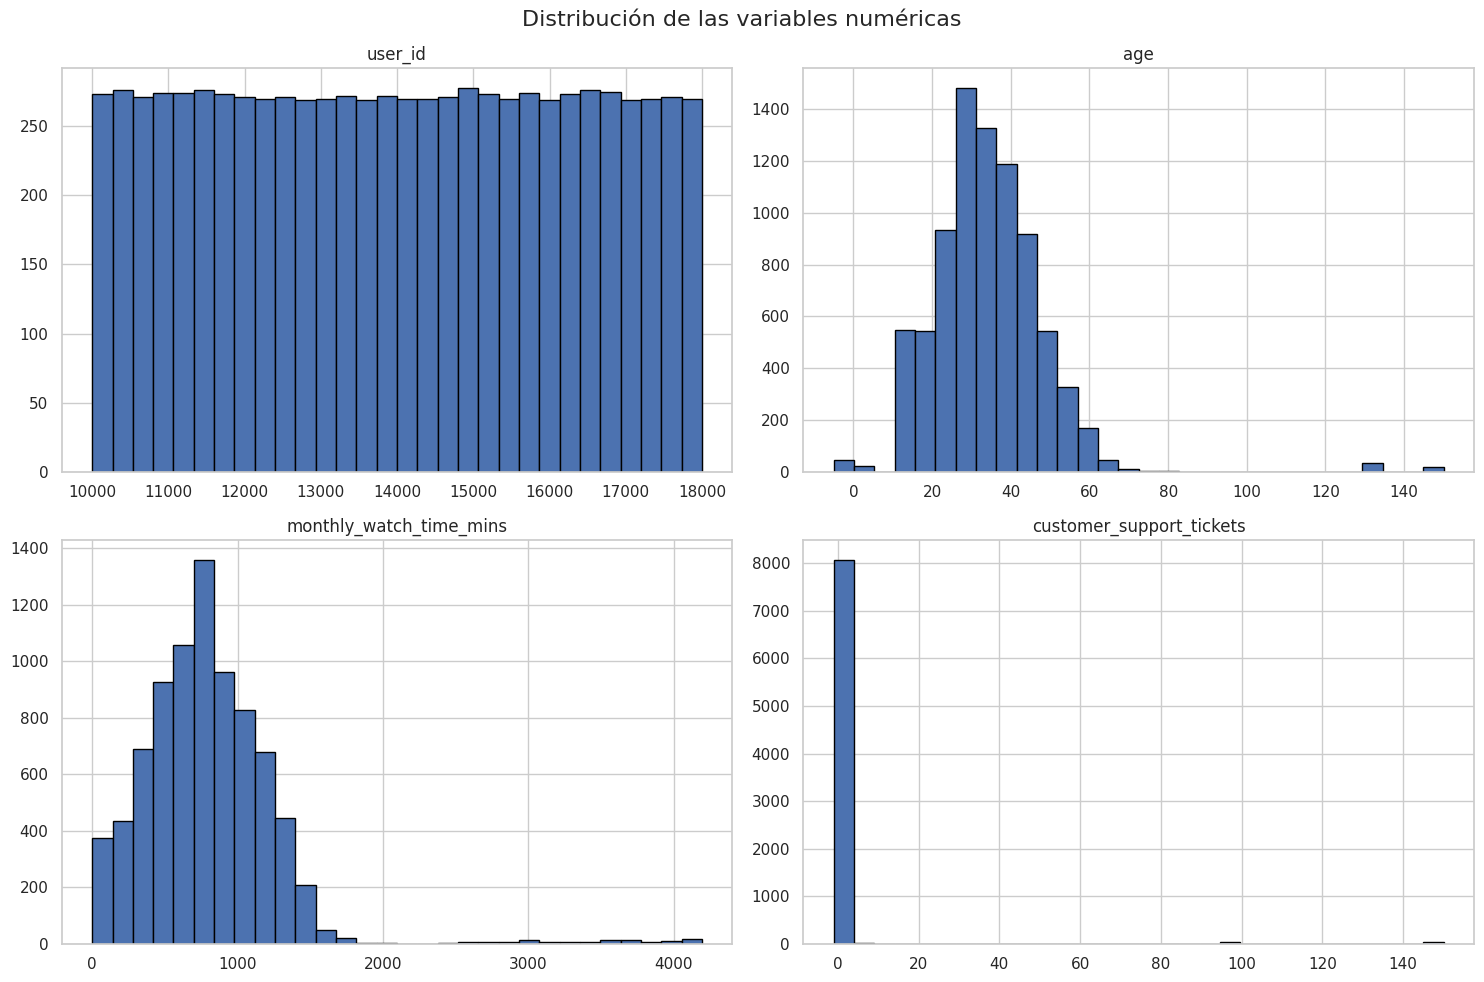

In [9]:
# Seleccionar variables numéricas
variables_numericas = df.select_dtypes(include=["int64", "float64"]).columns

# Crear histogramas
df[variables_numericas].hist(
    bins=30,
    figsize=(15, 10),
    edgecolor="black"
)

plt.suptitle("Distribución de las variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()

### Interpretación de los resultados

Los histogramas permiten complementar las estadísticas descriptivas al visualizar la forma de distribución de las variables numéricas presentes en el conjunto de datos.

La variable **user_id** presenta una distribución prácticamente uniforme, lo cual resulta esperable al tratarse de un identificador único asignado a cada usuario. Desde el punto de vista analítico, esta variable no aporta información sobre el comportamiento de los usuarios y, por lo tanto, no será considerada en análisis estadísticos posteriores.

La distribución de la variable **age** muestra una mayor concentración de usuarios entre los **25 y 45 años**, con un pico cercano a los **30-35 años**. Asimismo, se observan algunos valores extremadamente bajos y elevados, como edades negativas o superiores a los 100 años, que constituyen observaciones atípicas y deberán ser analizadas con mayor detalle en la etapa de detección de valores extremos.

En la variable **monthly_watch_time_mins** se aprecia una distribución con ligera asimetría positiva. La mayor parte de los usuarios registra tiempos mensuales de visualización comprendidos aproximadamente entre **500 y 1.200 minutos**, mientras que un reducido número de observaciones presenta valores considerablemente superiores, generando una cola hacia la derecha. Este comportamiento es consistente con la existencia de usuarios con un consumo excepcionalmente elevado de contenido.

Por último, la variable **customer_support_tickets** evidencia una distribución altamente concentrada en valores bajos, indicando que la mayoría de los usuarios genera pocos o ningún ticket de soporte. No obstante, se identifican algunos valores extremadamente altos que representan posibles observaciones atípicas y que deberán evaluarse en el análisis específico de outliers.

En conjunto, las distribuciones observadas muestran que las variables cuantitativas presentan comportamientos diferenciados y permiten identificar preliminarmente la presencia de valores extremos, los cuales serán estudiados mediante técnicas gráficas específicas en las siguientes etapas del análisis exploratorio.

## Paso 7. Distribución de las variables categóricas

Las variables categóricas describen características cualitativas de los registros y permiten identificar la composición del conjunto de datos según distintas categorías.

En esta sección se analizan las frecuencias absolutas de las principales variables categóricas mediante gráficos de barras, con el objetivo de identificar categorías predominantes, posibles desbalances y patrones generales en la distribución de los datos.

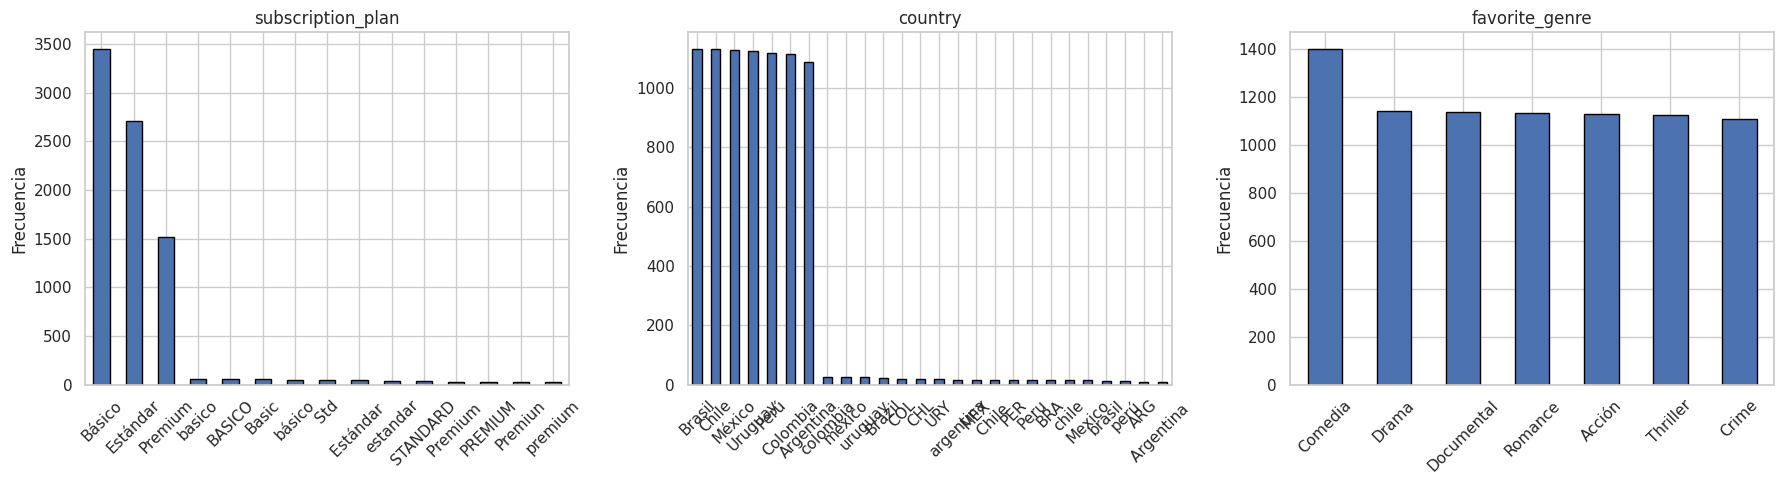

In [10]:
# Variables categóricas (excluyendo fechas)
variables_categoricas = [
    "subscription_plan",
    "country",
    "favorite_genre"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, columna in zip(axes, variables_categoricas):
    df[columna].value_counts().plot(
        kind="bar",
        ax=ax,
        edgecolor="black"
    )
    ax.set_title(columna)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Normalización complementaria de variables categóricas

Durante la inspección de las distribuciones de frecuencia se identificaron categorías equivalentes representadas mediante diferentes variantes de escritura (por ejemplo, diferencias en mayúsculas, acentos, abreviaturas e idioma).

Con el objetivo de obtener una representación más fiel de la distribución de estas variables, se realiza una normalización complementaria de las categorías antes de continuar con el análisis exploratorio.

Esta transformación no modifica la información contenida en el conjunto de datos, sino que unifica distintas representaciones de una misma categoría para facilitar su interpretación.

In [11]:
# Crear una copia del dataset para el EDA
df_eda = df.copy()

In [16]:
# Normalización de los planes de suscripción
planes = {
    "basic": "Básico",
    "basico": "Básico",
    "básico": "Básico",
    "BASICO": "Básico",
    "Basic": "Básico",

    "std": "Estándar",
    "estandar": "Estándar",
    "estándar": "Estándar",
    "STANDARD": "Estándar",
    "Std": "Estándar",

    "premium": "Premium",
    "PREMIUM": "Premium",
    "Premiun": "Premium",
    "Premium": "Premium",
}

df_eda["subscription_plan"] = (
    df_eda["subscription_plan"]
    .str.strip()
    .replace(planes)
)

In [19]:
# Normalización de países
paises = {
    # Argentina
    "arg": "Argentina",
    "ARG": "Argentina",
    "ar": "Argentina",
    "AR": "Argentina",
    "argentina": "Argentina",
    "Argentina": "Argentina",

    # Brasil
    "bra": "Brasil",
    "BRA": "Brasil",
    "br": "Brasil",
    "BR": "Brasil",
    "brazil": "Brasil",
    "Brasil": "Brasil",
    "Brazil": "Brasil",
    "brasil": "Brasil",

    # Chile
    "chl": "Chile",
    "CHL": "Chile",
    "cl": "Chile",
    "CL": "Chile",
    "chile": "Chile",
    "Chile": "Chile",

    # Colombia
    "col": "Colombia",
    "COL": "Colombia",
    "co": "Colombia",
    "CO": "Colombia",
    "colombia": "Colombia",
    "Colombia": "Colombia",

    # México
    "mex": "México",
    "MEX": "México",
    "mx": "México",
    "MX": "México",
    "mexico": "México",
    "méxico": "México",
    "México": "México",
    "Mexico": "México",

    # Perú
    "per": "Perú",
    "PER": "Perú",
    "pe": "Perú",
    "PE": "Perú",
    "peru": "Perú",
    "perú": "Perú",
    "Perú": "Perú",
    "Peru": "Perú",

    # Uruguay
    "ury": "Uruguay",
    "URY": "Uruguay",
    "uy": "Uruguay",
    "UY": "Uruguay",
    "uruguay": "Uruguay",
    "Uruguay": "Uruguay"
}

df_eda["country"] = (
    df_eda["country"]
    .astype(str)
    .str.strip()
    .replace(paises)
)

In [22]:
df_eda["subscription_plan"].value_counts()

,count
subscription_plan,
Básico,3664
Estándar,2875
Premium,1621


In [23]:
df_eda["country"].value_counts()

,count
country,
México,1185
Chile,1181
Brasil,1181
Uruguay,1165
Perú,1163
Colombia,1162
Argentina,1123


In [24]:
# A partir de este punto, el análisis exploratorio continuará
# utilizando la versión normalizada del conjunto de datos.

df = df_eda.copy()

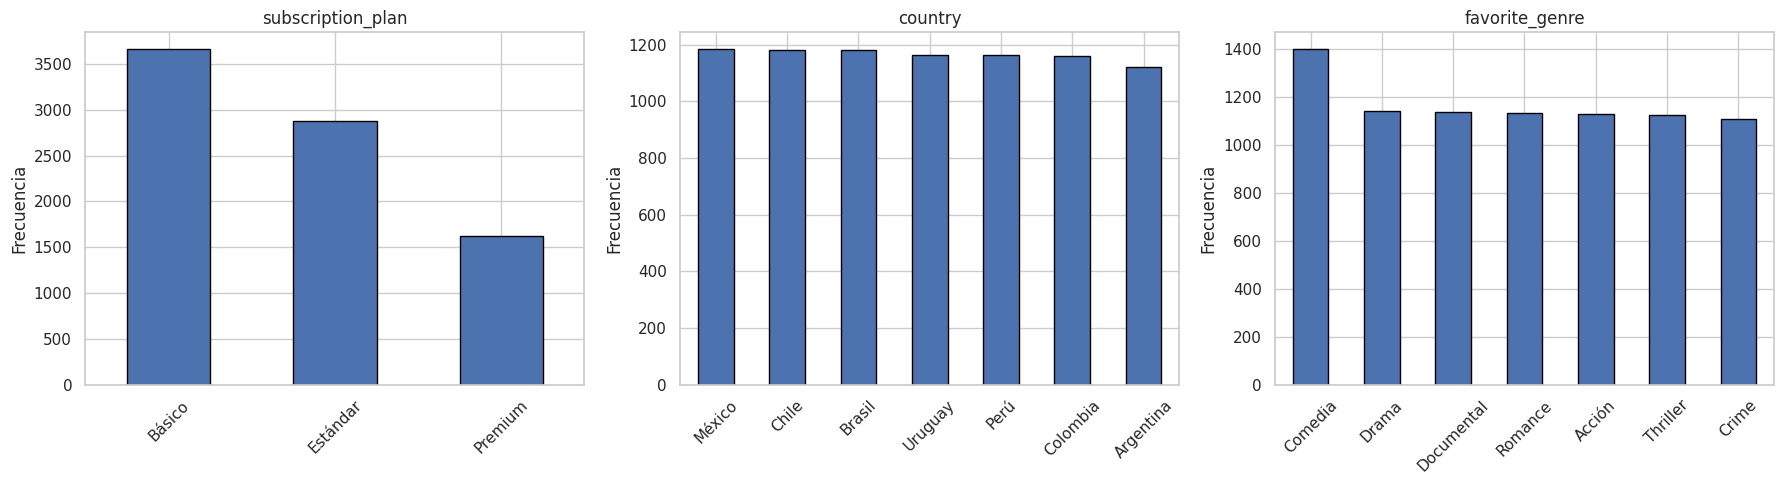

In [26]:
# Nuevamente ejecuto la dstribución
variables_categoricas = [
    "subscription_plan",
    "country",
    "favorite_genre"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, columna in zip(axes, variables_categoricas):
    df[columna].value_counts().plot(
        kind="bar",
        ax=ax,
        edgecolor="black"
    )
    ax.set_title(columna)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 8. Análisis de valores atípicos (Outliers)

Los valores atípicos u *outliers* corresponden a observaciones que se alejan considerablemente del comportamiento general de los datos.

Su identificación constituye una etapa importante dentro del Análisis Exploratorio de Datos, ya que estos registros pueden deberse a errores de carga, inconsistencias en la información o representar casos reales poco frecuentes.

En esta sección se emplean diagramas de caja (*boxplots*), los cuales permiten visualizar la dispersión de las variables numéricas e identificar de forma preliminar posibles observaciones atípicas.

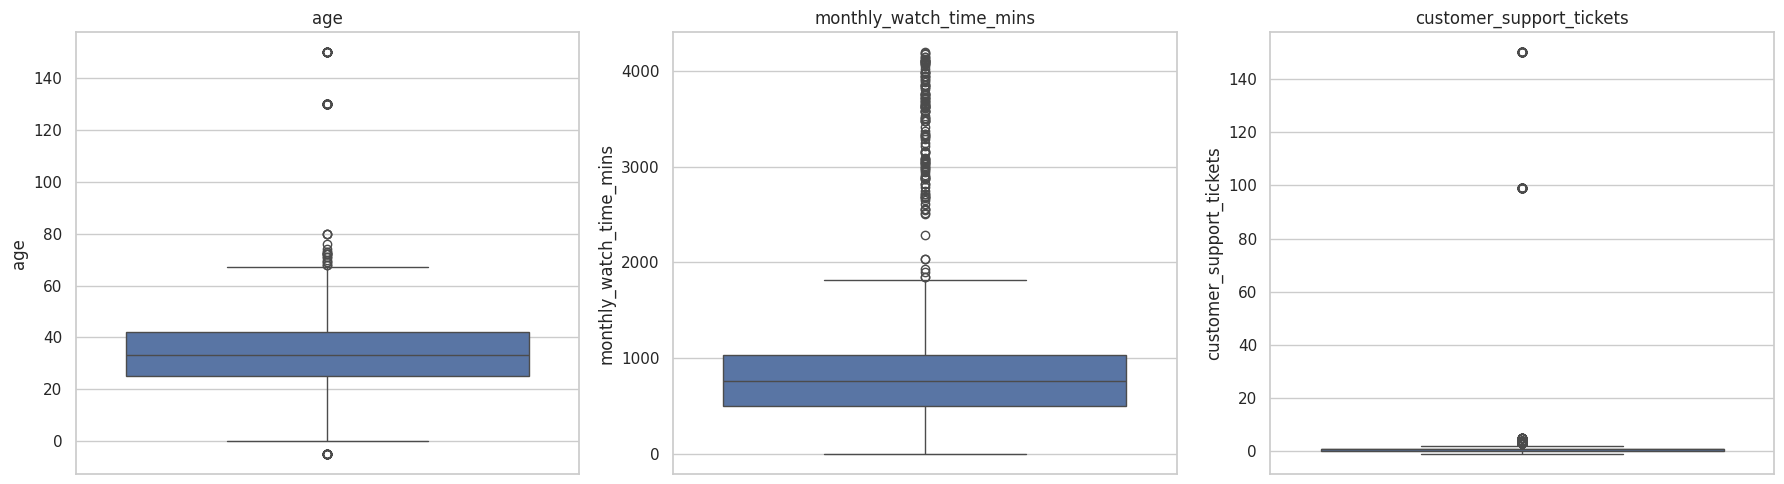

In [27]:
# Variables numéricas de análisis
variables_numericas = [
    "age",
    "monthly_watch_time_mins",
    "customer_support_tickets"
]

# Crear los boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, columna in zip(axes, variables_numericas):
    sns.boxplot(
        y=df[columna],
        ax=ax
    )
    ax.set_title(columna)

plt.tight_layout()
plt.show()

### Interpretación de los resultados

Los diagramas de caja permitieron identificar la presencia de valores atípicos en las tres variables numéricas analizadas.

En la variable **age**, la mayor parte de las observaciones se concentra aproximadamente entre los **25 y 42 años**, con una mediana cercana a los **33 años**. No obstante, se identifican valores atípicos tanto por debajo del límite inferior, incluyendo una edad negativa, como por encima del límite superior, destacándose registros cercanos a los **130 y 150 años**. Estas observaciones podrían corresponder a errores de registro o a datos excepcionales y deberán considerarse con cautela en etapas posteriores.

La variable **monthly_watch_time_mins** presenta una distribución con una importante cantidad de valores atípicos superiores. Si bien la mayoría de los usuarios registra tiempos de visualización inferiores a los **1.800 minutos mensuales**, se observan numerosos casos que superan ampliamente dicho valor, alcanzando aproximadamente los **4.200 minutos**. Estos registros podrían representar usuarios con un consumo intensivo de contenido o comportamientos poco frecuentes dentro de la población analizada.

Por su parte, la variable **customer_support_tickets** evidencia una fuerte concentración en valores bajos, lo que indica que la mayoría de los usuarios realiza pocas consultas al servicio de soporte. Sin embargo, también se observan algunos valores extremos, especialmente registros cercanos a **100 y 150 tickets**, que se encuentran claramente alejados del comportamiento general y podrían representar situaciones excepcionales o inconsistencias en los datos.

En conjunto, el análisis confirma la existencia de valores atípicos en las variables numéricas. No obstante, dado que estos registros pueden contener información relevante sobre comportamientos poco frecuentes, se decidió conservarlos para los análisis posteriores, limitándose en esta etapa a documentar su presencia y evaluar su posible impacto en la interpretación de los resultados.

## Paso 9. Análisis bivariado

Una vez analizadas las variables de forma individual, el siguiente paso consiste en estudiar las relaciones existentes entre ellas.

El análisis bivariado permite identificar diferencias entre grupos, detectar patrones de comportamiento y explorar posibles asociaciones entre variables categóricas y numéricas.

En esta primera etapa se analiza la relación entre el plan de suscripción y el tiempo mensual de visualización, con el objetivo de determinar si existen diferencias en el consumo de contenido según el tipo de suscripción contratado.

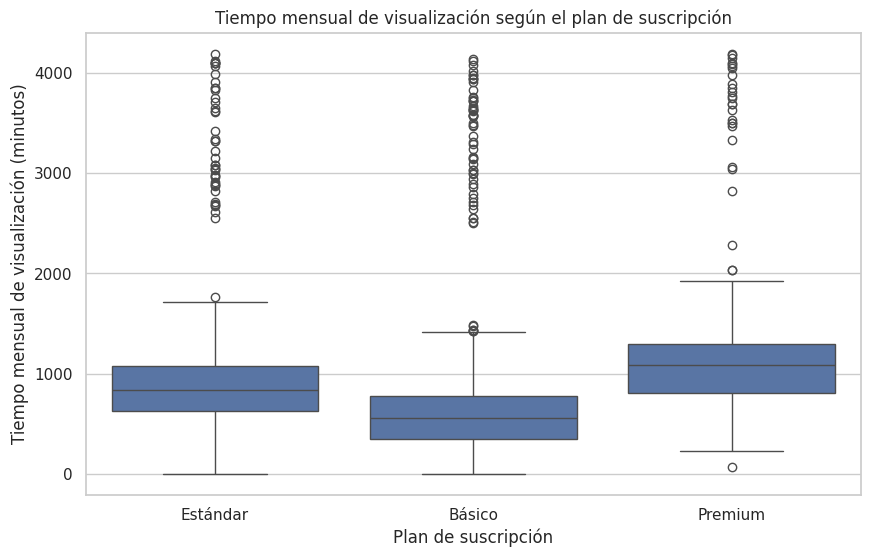

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="subscription_plan",
    y="monthly_watch_time_mins"
)

plt.title("Tiempo mensual de visualización según el plan de suscripción")
plt.xlabel("Plan de suscripción")
plt.ylabel("Tiempo mensual de visualización (minutos)")

plt.show()

### Interpretación de los resultados

El análisis del tiempo mensual de visualización según el plan de suscripción evidencia diferencias en el comportamiento de consumo entre los distintos tipos de usuarios.

Los usuarios del plan **Premium** presentan la mediana más alta de tiempo de visualización, así como un rango intercuartílico superior al observado en los planes **Estándar** y **Básico**. Este comportamiento sugiere que los usuarios con una suscripción Premium tienden a consumir una mayor cantidad de contenido de forma regular.

Por su parte, el plan **Estándar** muestra un nivel de consumo intermedio, mientras que los usuarios del plan **Básico** registran, en términos generales, los menores tiempos de visualización mensual.

En los tres planes se observa la presencia de valores atípicos superiores, correspondientes a usuarios con un consumo excepcionalmente elevado de contenido. La existencia de estos registros en todas las categorías indica que el alto consumo no es exclusivo de un único plan de suscripción, aunque el comportamiento típico de los usuarios Premium continúa siendo superior al de los demás grupos.

En conjunto, este análisis sugiere una asociación entre el tipo de suscripción y el tiempo de visualización mensual, observándose una tendencia creciente del consumo a medida que aumenta el nivel del plan contratado.

### Edad según el plan de suscripción

Con el fin de profundizar el análisis bivariado, se estudia la relación entre la edad de los usuarios y el plan de suscripción contratado.

Este análisis permite identificar si existen diferencias en la distribución de edades entre los distintos planes, lo que podría sugerir preferencias de contratación asociadas a determinados grupos etarios. Para ello se utiliza un diagrama de caja (*boxplot*), ya que facilita la comparación de la mediana, la dispersión y la presencia de valores atípicos entre categorías.

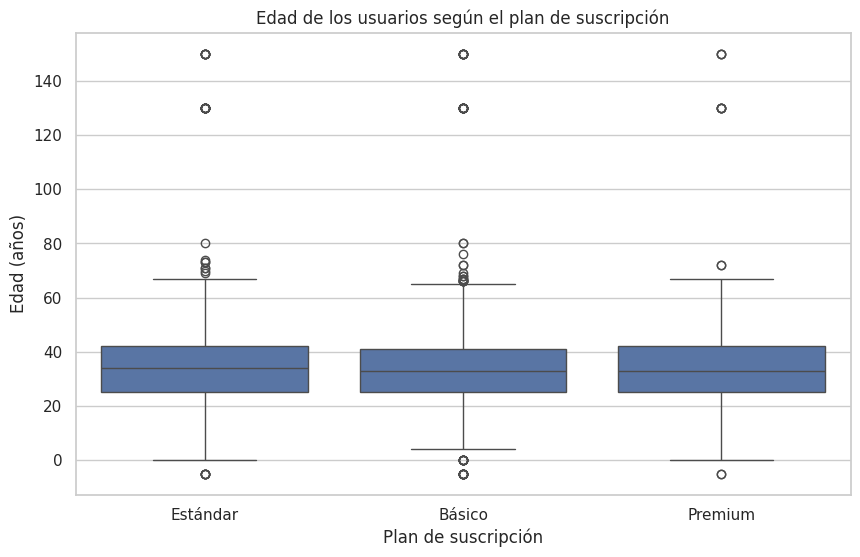

In [29]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="subscription_plan",
    y="age"
)

plt.title("Edad de los usuarios según el plan de suscripción")
plt.xlabel("Plan de suscripción")
plt.ylabel("Edad (años)")

plt.show()

### Interpretación de los resultados

El análisis de la edad según el plan de suscripción muestra que las distribuciones de los tres grupos son muy similares.

Las medianas de edad para los planes **Básico**, **Estándar** y **Premium** se encuentran próximas entre sí, alrededor de los **33 años**, mientras que los rangos intercuartílicos presentan una amplitud comparable. Esto indica que la mayor parte de los usuarios de los distintos planes pertenece a un mismo rango etario.

Asimismo, en los tres planes se observan valores atípicos tanto inferiores como superiores, incluyendo edades negativas y registros cercanos a los **130 y 150 años**. La presencia de estos valores extremos es consistente con el análisis univariado realizado previamente y no modifica el comportamiento general de las distribuciones.

En conjunto, el gráfico no evidencia diferencias significativas en la edad de los usuarios según el plan de suscripción. Esto sugiere que, dentro del conjunto de datos analizado, la edad no parece constituir un factor determinante en la elección del tipo de suscripción.

### Cantidad de tickets de soporte según el plan de suscripción

En esta sección se analiza la relación entre el plan de suscripción y la cantidad de tickets generados por los usuarios.

El objetivo es determinar si existen diferencias en la utilización del servicio de soporte entre los distintos planes contratados. Para ello se emplea un diagrama de caja (*boxplot*), que permite comparar la distribución de los tickets de soporte en cada categoría e identificar posibles diferencias en el comportamiento de los usuarios.

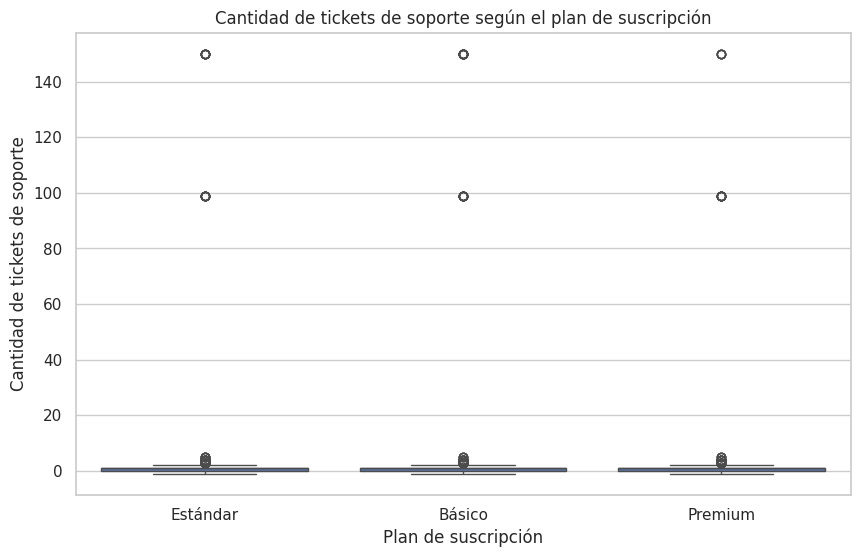

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="subscription_plan",
    y="customer_support_tickets"
)

plt.title("Cantidad de tickets de soporte según el plan de suscripción")
plt.xlabel("Plan de suscripción")
plt.ylabel("Cantidad de tickets de soporte")

plt.show()

### Interpretación de los resultados

El análisis de la cantidad de tickets de soporte según el plan de suscripción muestra distribuciones muy similares entre los tres grupos de usuarios.

Las medianas de los planes **Básico**, **Estándar** y **Premium** son prácticamente iguales y se ubican próximas a cero, indicando que la mayoría de los usuarios genera una cantidad muy reducida de consultas al servicio de soporte, independientemente del plan contratado.

Asimismo, la dispersión observada en los tres grupos es comparable, sin evidenciar diferencias significativas en la variabilidad de la cantidad de tickets registrados.

En los tres planes se identifican valores atípicos superiores, incluyendo algunos registros extremadamente elevados. Sin embargo, estos casos representan una proporción muy pequeña del conjunto de datos y aparecen distribuidos en todas las categorías, por lo que no parecen estar asociados a un plan de suscripción específico.

En conjunto, el análisis sugiere que el tipo de plan contratado no presenta una relación evidente con la cantidad de tickets generados por los usuarios. La utilización del servicio de soporte muestra un comportamiento similar en los tres grupos analizados.

### Tiempo mensual de visualización según el género favorito

En esta sección se analiza la relación entre el género favorito de los usuarios y su tiempo mensual de visualización.

El objetivo es identificar si existen diferencias en el consumo de contenido según las preferencias de género. Para ello se utiliza un diagrama de caja (*boxplot*), el cual permite comparar la distribución del tiempo de visualización entre las distintas categorías e identificar posibles diferencias en la mediana, la dispersión y la presencia de valores atípicos.

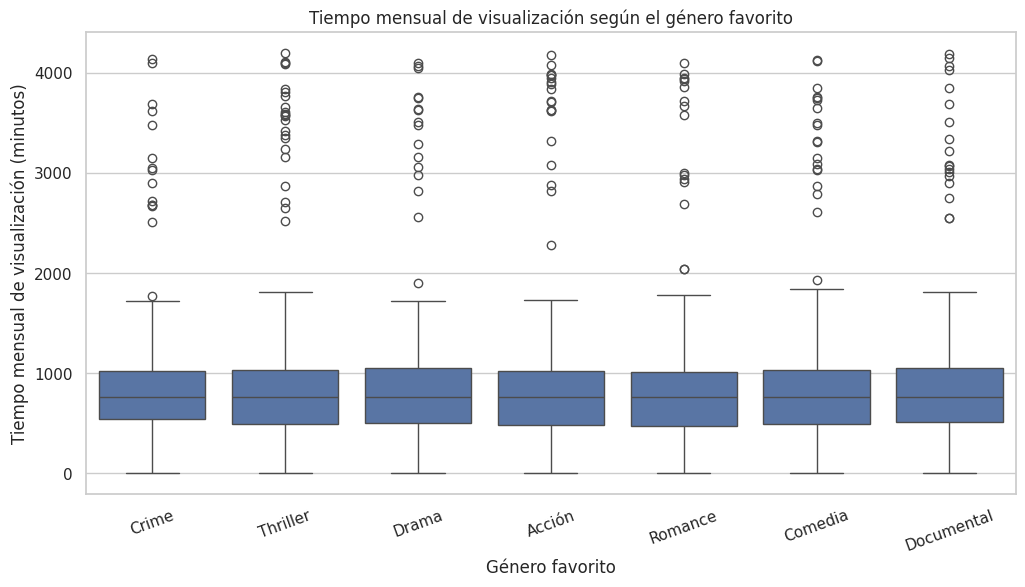

In [31]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="favorite_genre",
    y="monthly_watch_time_mins"
)

plt.title("Tiempo mensual de visualización según el género favorito")
plt.xlabel("Género favorito")
plt.ylabel("Tiempo mensual de visualización (minutos)")

plt.xticks(rotation=20)

plt.show()

### Interpretación de los resultados

El análisis del tiempo mensual de visualización según el género favorito muestra distribuciones muy similares entre todas las categorías consideradas.

Las medianas de tiempo de visualización presentan valores cercanos entre sí, al igual que los rangos intercuartílicos, lo que indica que el comportamiento de consumo resulta comparable independientemente del género preferido por los usuarios.

Asimismo, en todos los géneros se observa la presencia de valores atípicos superiores, correspondientes a usuarios con tiempos de visualización considerablemente mayores al promedio. Estos registros aparecen distribuidos en todas las categorías y no evidencian una concentración particular en un género específico.

En conjunto, el análisis no muestra diferencias significativas en el tiempo mensual de visualización según el género favorito. Esto sugiere que, dentro del conjunto de datos analizado, las preferencias de género no parecen influir de manera importante en la cantidad de contenido consumido por los usuarios.

## Paso 10. Matriz de correlaciones

La matriz de correlaciones permite evaluar la intensidad y la dirección de la relación lineal entre las variables numéricas del conjunto de datos.

Este análisis facilita la identificación de asociaciones positivas o negativas entre los atributos, permitiendo detectar posibles relaciones relevantes que podrían ser consideradas en etapas posteriores del proceso de minería de datos, como la selección de variables o la construcción de modelos predictivos.

Para este análisis se emplea el coeficiente de correlación de Pearson, cuyos valores oscilan entre -1 y 1. Valores próximos a 1 indican una relación lineal positiva fuerte, valores cercanos a -1 representan una relación lineal negativa fuerte y valores próximos a 0 sugieren ausencia de relación lineal.

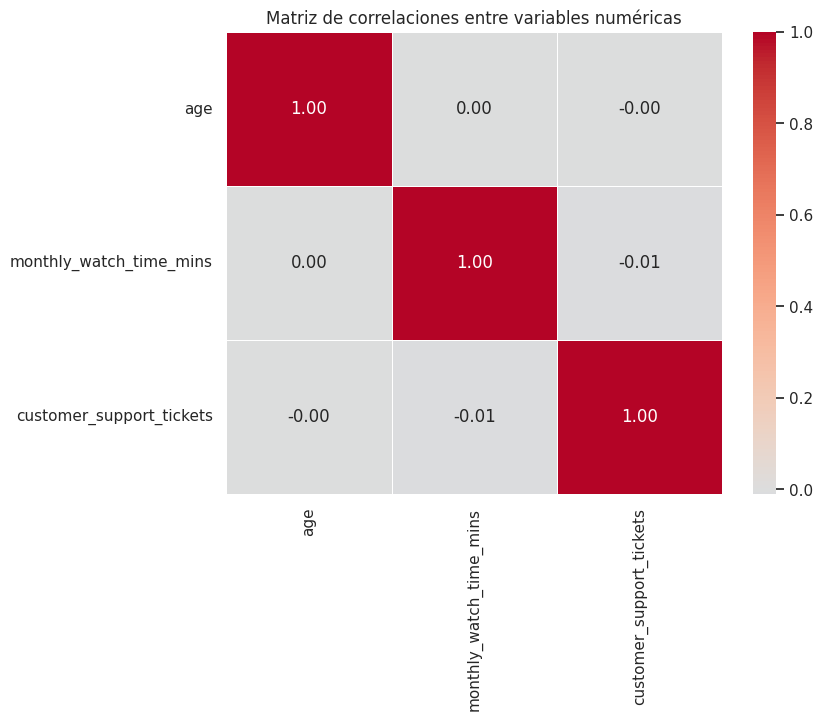

In [32]:
# Seleccionar únicamente las variables numéricas de interés
variables_corr = [
    "age",
    "monthly_watch_time_mins",
    "customer_support_tickets"
]

# Calcular la matriz de correlaciones
correlacion = df[variables_corr].corr()

# Visualizar la matriz
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlaciones entre variables numéricas")

plt.show()

### Interpretación de los resultados

La matriz de correlaciones muestra que las variables numéricas del conjunto de datos presentan coeficientes de correlación muy próximos a cero.

En particular, la relación entre **age** y **monthly_watch_time_mins** es prácticamente nula, indicando que la edad de los usuarios no presenta una asociación lineal con el tiempo mensual de visualización.

Del mismo modo, la correlación entre **age** y **customer_support_tickets** también resulta prácticamente inexistente, lo que sugiere que la cantidad de consultas al servicio de soporte no depende de la edad de los usuarios.

Finalmente, la relación entre **monthly_watch_time_mins** y **customer_support_tickets** presenta un coeficiente cercano a cero y ligeramente negativo. Este valor indica la ausencia de una relación lineal significativa entre ambas variables, por lo que un mayor tiempo de visualización no implica necesariamente una mayor o menor cantidad de tickets de soporte.

En conjunto, el análisis de correlaciones indica que las variables numéricas estudiadas se comportan de manera prácticamente independiente desde el punto de vista lineal. Estos resultados son consistentes con las observaciones obtenidas durante el análisis bivariado, donde tampoco se identificaron asociaciones fuertes entre las variables analizadas.

## Paso 11. Conclusiones del Análisis Exploratorio de Datos

El análisis exploratorio permitió caracterizar el conjunto de datos y comprender el comportamiento de las principales variables antes de avanzar hacia etapas posteriores del proyecto.

En primer lugar, se verificó que el dataset presenta una estructura consistente, con una adecuada calidad de datos luego del proceso de limpieza realizado previamente. Durante el EDA se realizó una normalización complementaria de algunas variables categóricas para unificar diferentes representaciones de una misma categoría y mejorar la interpretación de los resultados.

Las variables numéricas mostraron distribuciones acordes al contexto del problema, aunque se identificaron valores atípicos en edad, tiempo mensual de visualización y cantidad de tickets de soporte. Dado que estos registros podrían representar comportamientos reales poco frecuentes, se decidió conservarlos para los análisis posteriores.

El análisis bivariado permitió identificar que el plan de suscripción presenta una asociación con el tiempo mensual de visualización, observándose un mayor consumo entre los usuarios del plan Premium. En cambio, no se encontraron diferencias relevantes en la distribución de edades, la cantidad de tickets de soporte ni el tiempo de visualización según el género favorito.

Finalmente, la matriz de correlaciones evidenció la ausencia de relaciones lineales significativas entre las variables numéricas analizadas, lo que indica que cada una aporta información diferente dentro del conjunto de datos.

En conjunto, el Análisis Exploratorio de Datos permitió comprender la estructura del dataset, detectar patrones relevantes y verificar que la información se encuentra en condiciones adecuadas para continuar con las siguientes etapas del proceso de minería de datos.

## Exportación del conjunto de datos actualizado

Como resultado del análisis exploratorio se realizó una normalización complementaria de algunas variables categóricas para unificar categorías equivalentes.

Con el objetivo de mantener la consistencia entre las siguientes etapas del proyecto, se exporta una nueva versión del conjunto de datos, que será utilizada en los notebooks posteriores.

In [34]:
# Exportar la versión final del dataset

ruta_salida = "/content/drive/MyDrive/PI_Mineria_Datos_1/data/processed/dataset_final.csv"

df.to_csv(ruta_salida, index=False)

print("Dataset exportado correctamente.")
print(f"Ubicación: {ruta_salida}")

Dataset exportado correctamente.
Ubicación: /content/drive/MyDrive/PI_Mineria_Datos_1/data/processed/dataset_final.csv
